# Exploração inicial do dataset de energia

Este notebook apresenta uma exploração inicial do dataset de consumo energético fornecido pela Câmara Municipal da Maia.

Objetivos desta exploração:

- compreender a estrutura do dataset;
- identificar variáveis relevantes para análise;
- avaliar a qualidade dos dados;
- observar o comportamento temporal das séries;
- realizar uma análise estatística inicial dos consumos.

In [1]:
import os
import zipfile
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pandas.plotting import autocorrelation_plot

plt.rcParams["figure.figsize"] = (12, 4)
sns.set_theme(style="whitegrid")

In [2]:
repo_datasets_path = Path("../PM2025-TSAnomalyDetection/example-timeseries")
repo_datasets_path

assert repo_datasets_path.exists(), "Caminho para os datasets não encontrado"

In [3]:
os.listdir(repo_datasets_path)

['aqualog.zip',
 'aqualog_11_2025.csv.zip',
 'Consumo15m.zip',
 'consumo15m_11_2025.csv.zip',
 'meteo_11_2025.csv.zip',
 'stcp.zip']

In [4]:
zip_path = repo_datasets_path / "consumo15m_11_2025.csv.zip"
zip_path

WindowsPath('../PM2025-TSAnomalyDetection/example-timeseries/consumo15m_11_2025.csv.zip')

In [5]:
with zipfile.ZipFile(zip_path) as z:
    print(z.namelist())

['consumo15m_11_2025.csv']


In [6]:
with zipfile.ZipFile(zip_path) as z:
    with z.open(z.namelist()[0]) as f:
        df_energia = pd.read_csv(f)

In [7]:
df_energia.head()

,CPE,tstamp,DadosdeConsumo,PotActiva,PotReactIndut,PotReactCapac
0,PT0002000089069203YG,2022-12-31 00:15:00,NaN,0.296,NaN,NaN
1,PT0002000089069203YG,2022-12-31 00:30:00,NaN,0.292,NaN,NaN
2,PT0002000089069203YG,2022-12-31 00:45:00,NaN,0.284,NaN,NaN
3,PT0002000089069203YG,2022-12-31 01:00:00,NaN,0.280,NaN,NaN
4,PT0002000089069203YG,2022-12-31 01:15:00,NaN,0.272,NaN,NaN


In [8]:
df_energia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5940182 entries, 0 to 5940181
Data columns (total 6 columns):
 #   Column          Dtype  
---  ------          -----  
 0   CPE             object 
 1   tstamp          object 
 2   DadosdeConsumo  float64
 3   PotActiva       float64
 4   PotReactIndut   float64
 5   PotReactCapac   float64
dtypes: float64(4), object(2)
memory usage: 271.9+ MB


In [9]:
df_energia.shape

(5940182, 6)

In [10]:
df_energia["tstamp"] = pd.to_datetime(df_energia["tstamp"])

In [11]:
df_energia = df_energia.sort_values("tstamp")

In [12]:
print("Início:", df_energia["tstamp"].min())
print("Fim:", df_energia["tstamp"].max())

Início: 2022-12-31 00:15:00
Fim: 2025-05-01 00:00:00


In [13]:
df_energia["CPE"].nunique()

91

In [14]:
df_energia.isna().sum()

CPE                     0
tstamp                  0
DadosdeConsumo    5940182
PotActiva               0
PotReactIndut     2271472
PotReactCapac     2271472
dtype: int64

### Observações iniciais

A análise de valores em falta mostra que:

- A variável **DadosdeConsumo** encontra-se praticamente vazia.
- A variável **PotActiva** apresenta cobertura completa.
- As variáveis reativas apresentam alguns valores em falta.

Assim, a variável **PotActiva** será considerada como variável principal para a análise exploratória e para as etapas seguintes do projeto.

### Visualização exploratória global

O gráfico seguinte mostra todas as medições de **PotActiva** ao longo do tempo.

Como mistura medições de todos os CPE, serve apenas para perceber a escala geral dos dados e a densidade temporal dos registos.

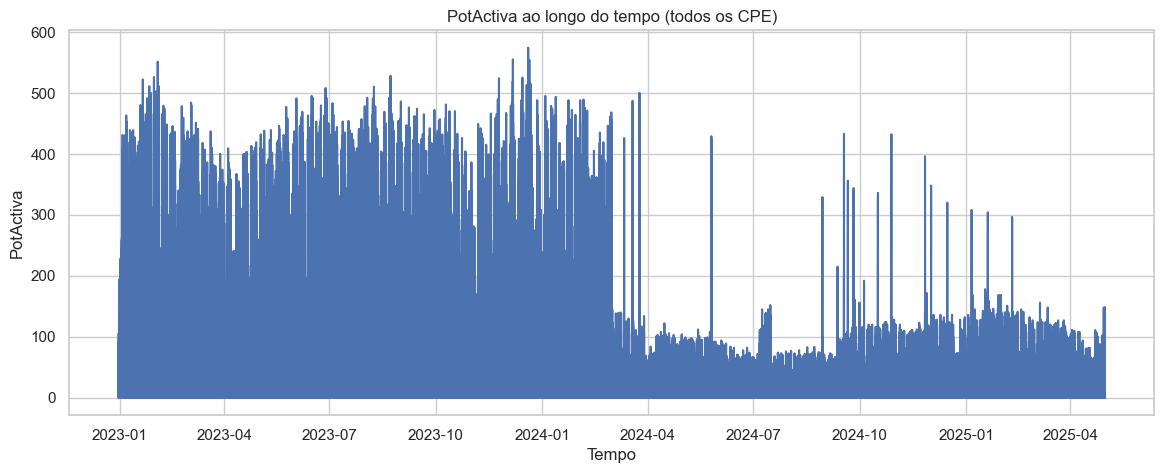

In [15]:
plt.figure(figsize=(14, 5))

plt.plot(df_energia["tstamp"], df_energia["PotActiva"])

plt.title("PotActiva ao longo do tempo (todos os CPE)")
plt.xlabel("Tempo")
plt.ylabel("PotActiva")

plt.show()

In [16]:
df_pivot = df_energia.pivot_table(
    index="tstamp",
    columns="CPE",
    values="PotActiva"
)

df_pivot.head()

CPE,PT0002000032936306KX,PT0002000032942455NH,PT0002000032959511HP,PT0002000032966446CC,PT0002000032968749YT,PT0002000032969229AC,PT0002000032976997LZ,PT0002000032990792KD,PT0002000032993611ME,PT0002000033016394FN,...,PT0002000119303492KB,PT0002000120237616VJ,PT0002000120320157HF,PT0002000123648159KR,PT0002000123801456QA,PT0002000125379984SH,PT0002000131605602FL,PT0002000133505542CK,PT0002000133685986TF,PT0002000201936109ME
tstamp,,,,,,,,,,,,,,,,,,,,,
2022-12-31 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,3.0,NaN,12.0,NaN,1.0,NaN,NaN,NaN,NaN
2022-12-31 00:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,3.0,NaN,13.0,NaN,1.0,NaN,NaN,NaN,NaN
2022-12-31 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,3.0,NaN,17.0,NaN,0.0,NaN,NaN,NaN,NaN
2022-12-31 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,2.0,NaN,16.0,NaN,1.0,NaN,NaN,NaN,NaN
2022-12-31 01:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,3.0,NaN,16.0,NaN,1.0,NaN,NaN,NaN,NaN


In [17]:
df_pivot.shape

(81777, 91)

In [18]:
missing_pct = df_pivot.isna().mean() * 100

missing_pct.sort_values().head(10)

CPE
PT0002000078233981HJ    0.015897
PT0002000068859393XH    0.015897
PT0002000033074862LZ    0.015897
PT0002000100113293JT    0.015897
PT0002000115031201VQ    0.015897
PT0002000105483259QH    0.017120
PT0002000068859187RL    0.017120
PT0002000068856906VS    0.018343
PT0002000068856781NM    0.018343
PT0002000073231742VK    0.018343
dtype: float64

In [19]:
cpe_melhor = missing_pct.sort_values().index[0]

cpe_melhor

'PT0002000078233981HJ'

In [20]:
serie_melhor = df_pivot[cpe_melhor]

serie_melhor.head()

tstamp
2022-12-31 00:15:00    0.0
2022-12-31 00:30:00    1.0
2022-12-31 00:45:00    1.0
2022-12-31 01:00:00    0.0
2022-12-31 01:15:00    1.0
Name: PT0002000078233981HJ, dtype: float64

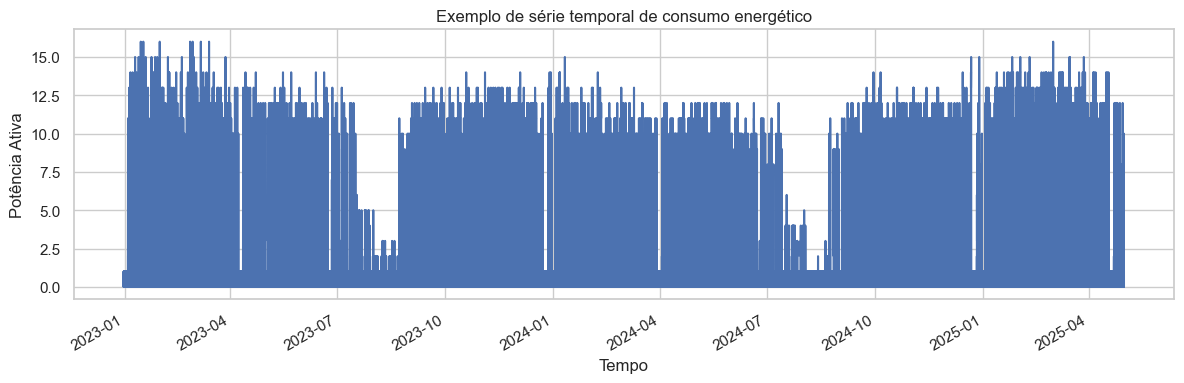

In [21]:
plt.figure(figsize=(12, 4))

serie_melhor.plot()

plt.title("Exemplo de série temporal de consumo energético")
plt.xlabel("Tempo")
plt.ylabel("Potência Ativa")

plt.tight_layout()
plt.show()

In [22]:
df_pivot.index.to_series().diff().value_counts().head()

tstamp
0 days 00:15:00    81770
0 days 01:15:00        3
0 days 00:30:00        3
Name: count, dtype: int64

## Análise estatística inicial

Para complementar a exploração anterior, seguem-se algumas análises estatísticas descritivas do dataset, incluindo consumos médios, agregações diárias e distribuição dos valores.

In [23]:
print("Número total de registos:", len(df_energia))
print("Número de CPE distintos:", df_energia["CPE"].nunique())
print("Período temporal:", df_energia["tstamp"].min(), "até", df_energia["tstamp"].max())

Número total de registos: 5940182
Número de CPE distintos: 91
Período temporal: 2022-12-31 00:15:00 até 2025-05-01 00:00:00


In [24]:
estatisticas_globais = df_energia["PotActiva"].describe()
estatisticas_globais

count    5.940182e+06
mean     8.093966e+00
std      2.301833e+01
min      0.000000e+00
25%      1.200000e-01
50%      2.000000e+00
75%      7.000000e+00
max      5.740000e+02
Name: PotActiva, dtype: float64

In [25]:
consumo_medio_por_cpe = df_pivot.mean().sort_values(ascending=False)
consumo_medio_por_cpe.head(10)

CPE
PT0002000078441876HB    218.212481
PT0002000114685657JR     46.470753
PT0002000100113293JT     42.290647
PT0002000068856781NM     31.704264
PT0002000068859325FL     31.504683
PT0002000068859597LS     29.197317
PT0002000081997398TD     27.679440
PT0002000068859393XH     24.428557
PT0002000068859382XF     20.488029
PT0002000077394934QY     20.475668
dtype: float64

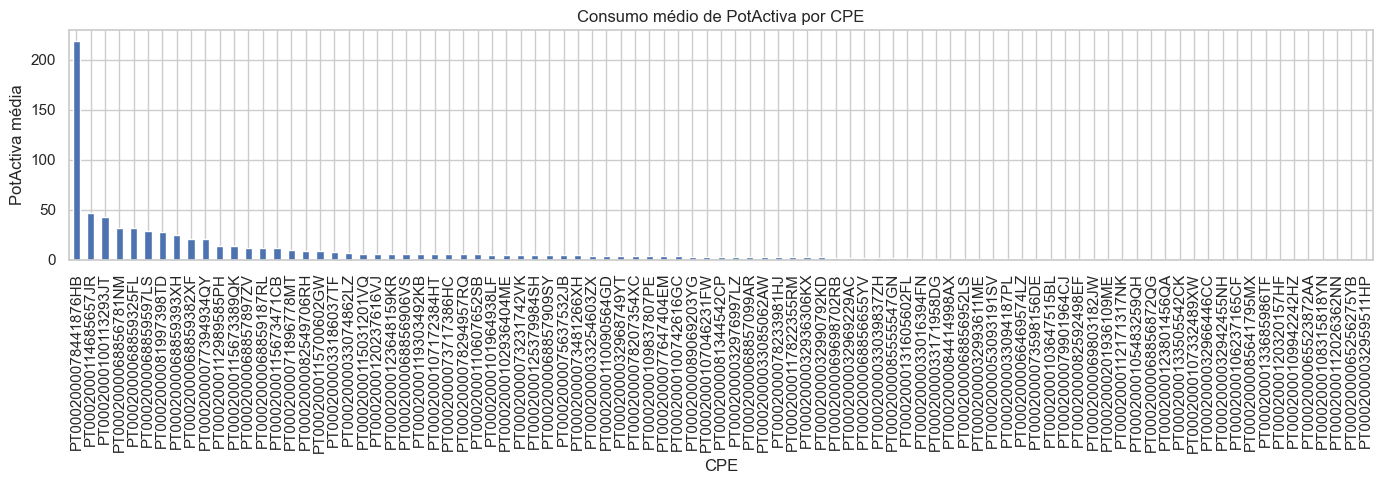

In [26]:
plt.figure(figsize=(14, 5))
consumo_medio_por_cpe.plot(kind="bar")
plt.title("Consumo médio de PotActiva por CPE")
plt.xlabel("CPE")
plt.ylabel("PotActiva média")
plt.tight_layout()
plt.show()

In [27]:
consumo_medio_global = df_pivot.mean().mean()
print("Consumo médio global:", consumo_medio_global)

Consumo médio global: 8.327627494333571


In [28]:
consumo_diario = df_pivot.resample("D").sum()
consumo_diario.head()

CPE,PT0002000032936306KX,PT0002000032942455NH,PT0002000032959511HP,PT0002000032966446CC,PT0002000032968749YT,PT0002000032969229AC,PT0002000032976997LZ,PT0002000032990792KD,PT0002000032993611ME,PT0002000033016394FN,...,PT0002000119303492KB,PT0002000120237616VJ,PT0002000120320157HF,PT0002000123648159KR,PT0002000123801456QA,PT0002000125379984SH,PT0002000131605602FL,PT0002000133505542CK,PT0002000133685986TF,PT0002000201936109ME
tstamp,,,,,,,,,,,,,,,,,,,,,
2022-12-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,146.0,329.0,0.000,388.0,0.000,104.0,0.0,0.000,0.0,0.0
2023-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,441.0,317.0,6.868,680.0,6.880,106.0,0.0,11.196,0.0,0.0
2023-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,216.0,365.0,7.004,825.0,3.520,106.0,0.0,11.232,0.0,0.0
2023-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1210.0,755.0,4.252,1523.0,3.292,653.0,0.0,11.224,0.0,0.0
2023-01-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1231.0,805.0,5.560,1555.0,3.068,596.0,0.0,11.204,0.0,0.0


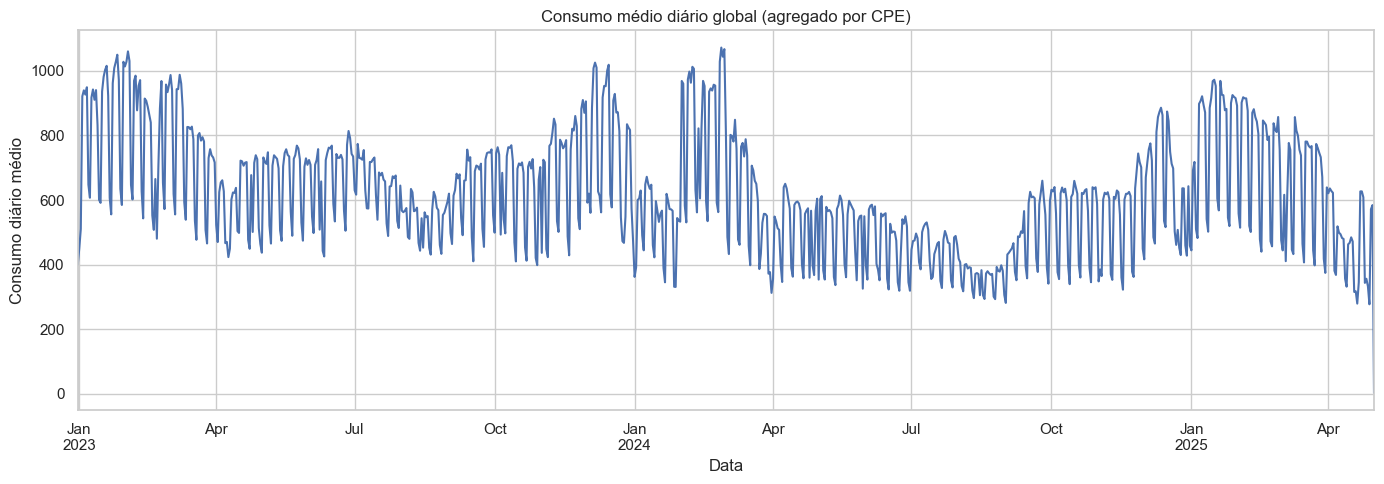

In [29]:
plt.figure(figsize=(14, 5))
consumo_diario.mean(axis=1).plot()
plt.title("Consumo médio diário global (agregado por CPE)")
plt.xlabel("Data")
plt.ylabel("Consumo diário médio")
plt.tight_layout()
plt.show()

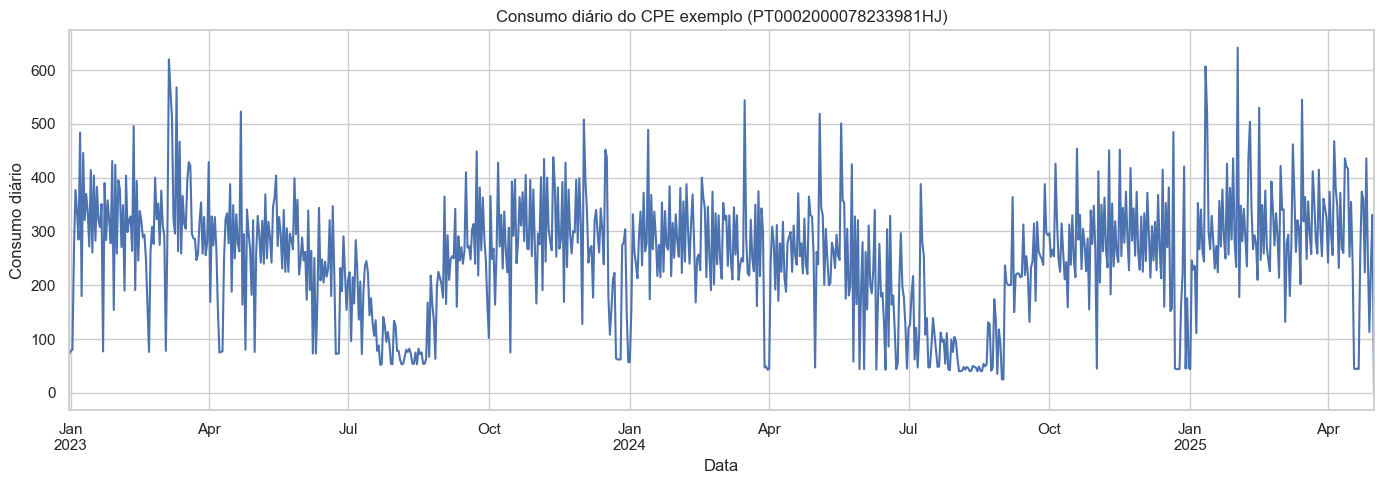

In [30]:
plt.figure(figsize=(14, 5))
consumo_diario[cpe_melhor].plot()
plt.title(f"Consumo diário do CPE exemplo ({cpe_melhor})")
plt.xlabel("Data")
plt.ylabel("Consumo diário")
plt.tight_layout()
plt.show()

In [31]:
consumo_medio_diario_por_cpe = consumo_diario.mean().sort_values(ascending=False)
consumo_medio_diario_por_cpe.head(10)

CPE
PT0002000078441876HB    10459.361665
PT0002000100113293JT     4053.754396
PT0002000068856781NM     3038.926143
PT0002000068859325FL     2909.991208
PT0002000068859597LS     2696.798359
PT0002000081997398TD     2653.072685
PT0002000114685657JR     2540.800703
PT0002000068859393XH     2341.590270
PT0002000077394934QY     1891.202814
PT0002000068859382XF     1890.086753
dtype: float64

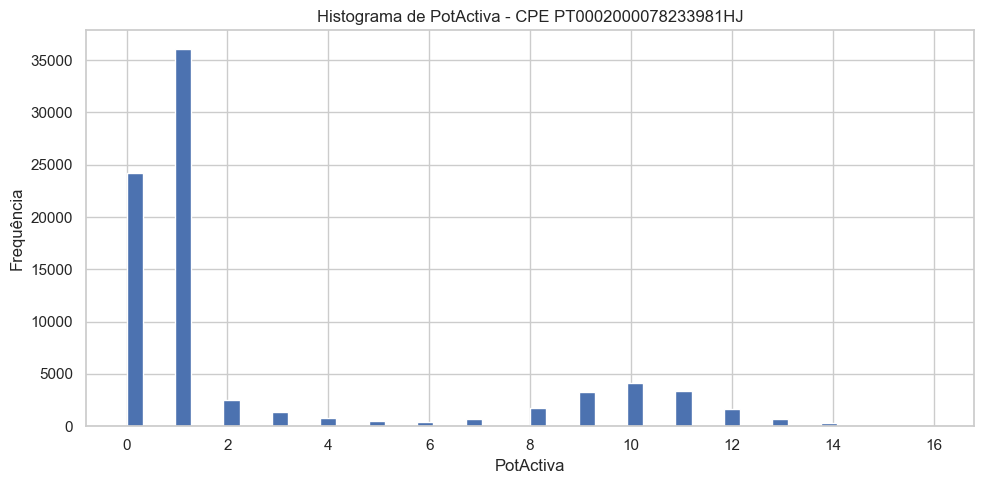

In [32]:
plt.figure(figsize=(10, 5))
plt.hist(serie_melhor.dropna(), bins=50)
plt.title(f"Histograma de PotActiva - CPE {cpe_melhor}")
plt.xlabel("PotActiva")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

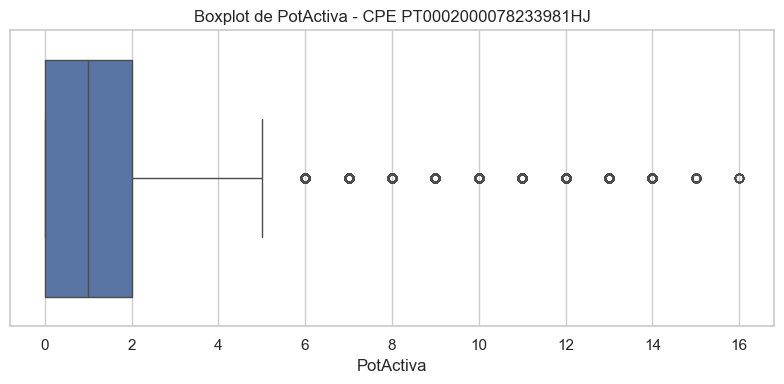

In [33]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=serie_melhor.dropna())
plt.title(f"Boxplot de PotActiva - CPE {cpe_melhor}")
plt.xlabel("PotActiva")
plt.tight_layout()
plt.show()

In [34]:
serie_melhor.describe()

count    81764.000000
mean         2.615833
std          3.828129
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max         16.000000
Name: PT0002000078233981HJ, dtype: float64

### Agregações temporais

As agregações seguintes ajudam a observar tendências e possíveis padrões sazonais em escalas temporais diferentes.

In [35]:
serie_melhor_diaria = serie_melhor.resample("D").mean()
serie_melhor_semanal = serie_melhor.resample("W").mean()
serie_melhor_mensal = serie_melhor.resample("M").mean()

C:\Users\gui30\AppData\Local\Temp\ipykernel_2616\2411344446.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  serie_melhor_mensal = serie_melhor.resample("M").mean()


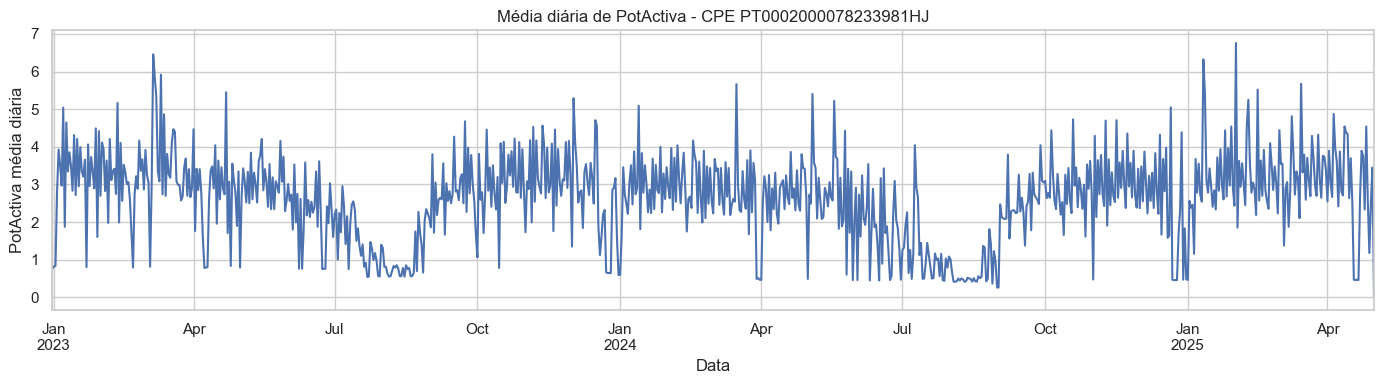

In [36]:
plt.figure(figsize=(14, 4))
serie_melhor_diaria.plot()
plt.title(f"Média diária de PotActiva - CPE {cpe_melhor}")
plt.xlabel("Data")
plt.ylabel("PotActiva média diária")
plt.tight_layout()
plt.show()

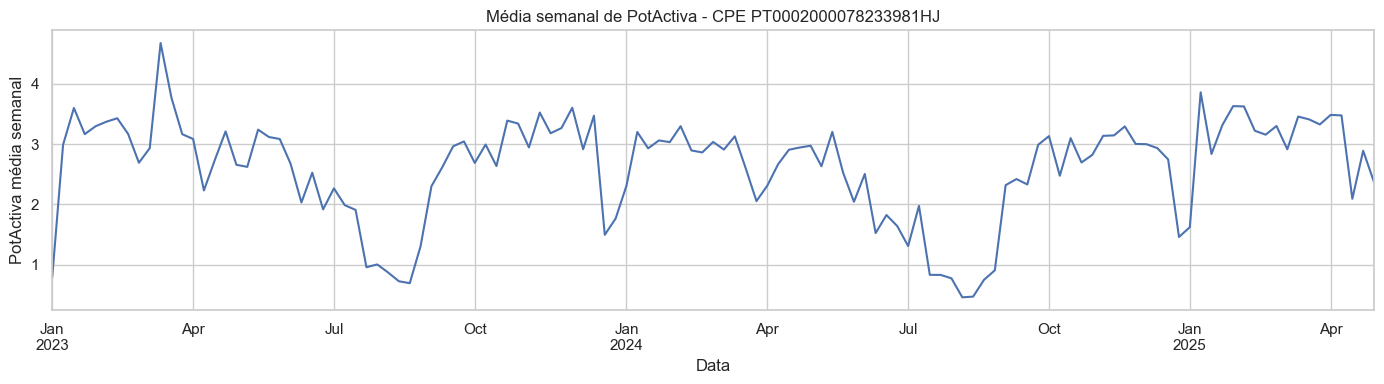

In [37]:
plt.figure(figsize=(14, 4))
serie_melhor_semanal.plot()
plt.title(f"Média semanal de PotActiva - CPE {cpe_melhor}")
plt.xlabel("Data")
plt.ylabel("PotActiva média semanal")
plt.tight_layout()
plt.show()

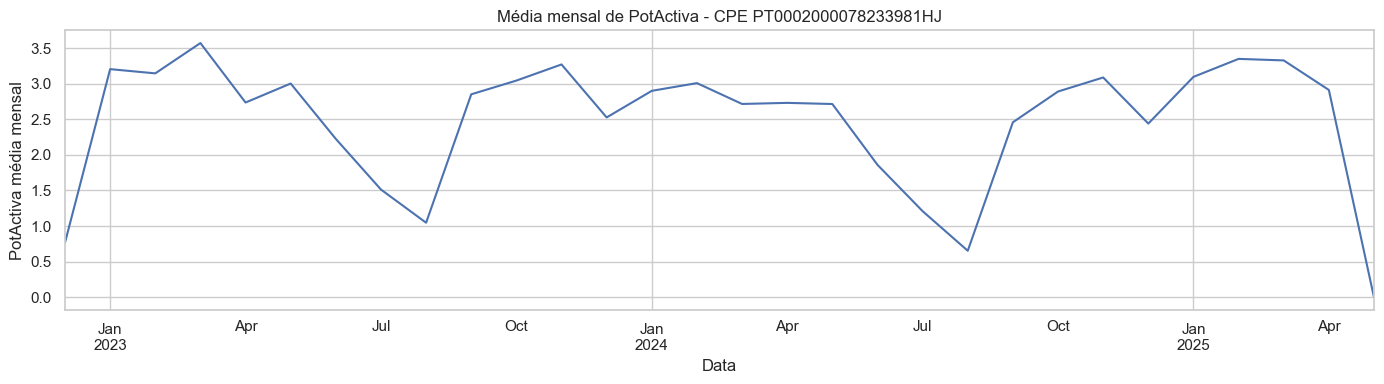

In [38]:
plt.figure(figsize=(14, 4))
serie_melhor_mensal.plot()
plt.title(f"Média mensal de PotActiva - CPE {cpe_melhor}")
plt.xlabel("Data")
plt.ylabel("PotActiva média mensal")
plt.tight_layout()
plt.show()

### Autocorrelação

A autocorrelação permite observar dependências temporais na série, sendo particularmente útil para perceber se existem padrões regulares de repetição.

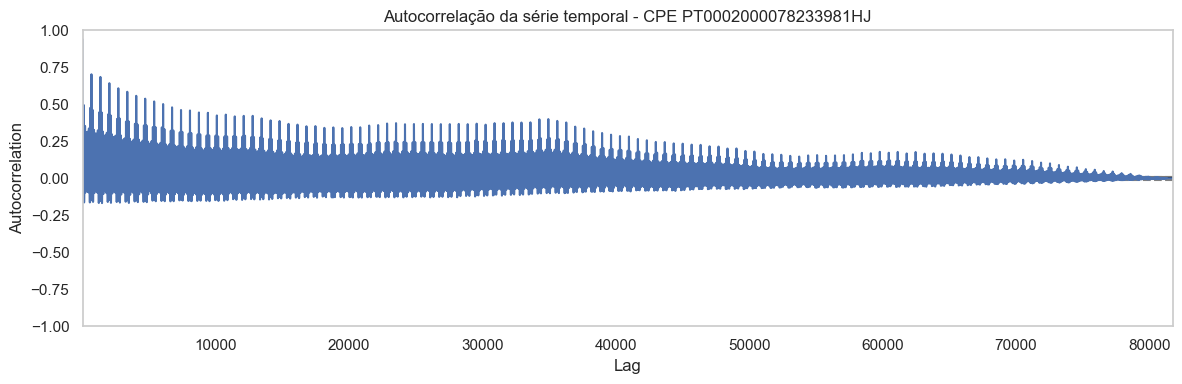

In [39]:
plt.figure(figsize=(12, 4))
autocorrelation_plot(serie_melhor.dropna())
plt.title(f"Autocorrelação da série temporal - CPE {cpe_melhor}")
plt.tight_layout()
plt.show()

In [40]:
freq_dominante = df_pivot.index.to_series().diff().value_counts().idxmax()
print("Frequência temporal dominante:", freq_dominante)

Frequência temporal dominante: 0 days 00:15:00


### Perfil médio diário de consumo

Para compreender melhor os padrões temporais do consumo energético,
calcula-se o perfil médio diário agregando os consumos por hora do dia.
Este gráfico permite observar padrões típicos de utilização ao longo
de um dia médio.

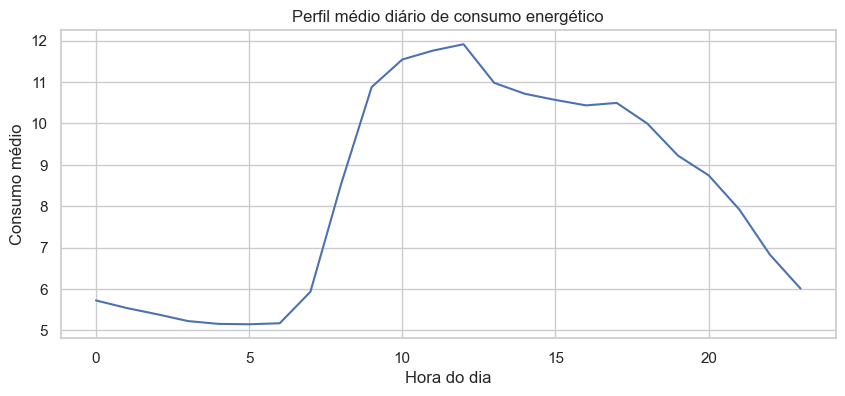

In [41]:
perfil_diario = df_pivot.copy()

perfil_diario["hora"] = perfil_diario.index.hour

perfil_medio = perfil_diario.groupby("hora").mean().mean(axis=1)

plt.figure(figsize=(10,4))
perfil_medio.plot()

plt.title("Perfil médio diário de consumo energético")
plt.xlabel("Hora do dia")
plt.ylabel("Consumo médio")

plt.show()

## Conclusões iniciais sobre o dataset de energia

- O dataset contém aproximadamente **5.9 milhões de registos** e **91 CPE distintos**, correspondendo a 91 séries temporais.
- O período temporal cobre aproximadamente os anos de **2022 a 2025**.
- A frequência dominante das medições é de **15 minutos**.
- A variável **PotActiva** apresenta cobertura completa e será a variável principal de análise.
- A análise estatística inicial mostra diferenças relevantes entre os consumos médios dos vários CPE.
- Os histogramas e boxplots sugerem a existência de valores extremos e picos de consumo que poderão ser relevantes para deteção de anomalias.
- As agregações diárias, semanais e mensais ajudam a identificar padrões temporais e possíveis comportamentos sazonais.
- A autocorrelação indica dependência temporal, o que reforça a adequação de métodos específicos para séries temporais nas fases seguintes do projeto.

In [42]:
estatisticas_por_cpe = df_pivot.describe().T
estatisticas_por_cpe.to_csv("../results/estatisticas_por_cpe.csv")

missing_pct.sort_values().to_csv("../results/missing_pct_por_cpe.csv")
consumo_medio_por_cpe.to_csv("../results/consumo_medio_por_cpe.csv")
consumo_medio_diario_por_cpe.to_csv("../results/consumo_medio_diario_por_cpe.csv")